In [1]:
import os
os.chdir('/workspace/3bca41f0-585a-4f75-923e-a9aa2d085e81')
print(os.listdir('.'))

['F5m_imag.npy', 'a.npy', 'a_n.npy', 'lambda_n.npy', 'F5p_t.npy', 'memory', 'peaks_features_F1_F12_normalized_full.csv', '.kernel_llm_logs_1.txt', 'F5p_imag.npy', 'F7_imag.npy', 'F6_imag.npy', ' v6 — Binding Context Document.pdf', 'c.npy', 'F6_real.npy', 'description.npy', 'F6_t.npy', 'F5m_t.npy', 'F1_imag.npy', 'F4_t.npy', '.config', 'N.npy', 'F1_real.npy', 'F2_imag.npy', 'F4_imag.npy', 'F1_t.npy', 'F7_t.npy', '.prompts', 'F2_t.npy', 'F7_real.npy', 'F5p_real.npy', 'F4_real.npy', 'F5m_real.npy', 'rho0.npy', 'F2_real.npy']


In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df['class'].value_counts() if 'class' in df.columns else df.head())

(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6

In [3]:
print(df['function'].value_counts())
print(df.groupby('function')['GRH'].first())

function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64
function
F1 True
F10 True
F11 True
F12 False
F2 True
F4 False
F5m False
F5p False
F6 True
F7 True
F9 True
Name: GRH, dtype: bool


In [4]:
# Check relationship between F*_t.npy peaks and CSV peaks
for fn in ['F1','F2','F4','F5m','F5p','F6','F7']:
 t_arr = np.load(f'{fn}_t.npy')
 df_t = df[df['function']==fn]['t'].values
 # Are they the same set?
 match = np.allclose(np.sort(t_arr), np.sort(df_t))
 print(fn, 'npy len', len(t_arr), 'csv len', len(df_t), 'sorted match:', match,
 'first few npy', t_arr[:3], 'first few csv', df_t[:3])

F1 npy len 200 csv len 200 sorted match: False first few npy [22299.04000002 24329.62000002 26296.93000003] first few csv [77403.70000025 74956.00000024 94526.80000031]
F2 npy len 200 csv len 200 sorted match: False first few npy [17859.88000001 20679.04000002 22709.71000002] first few csv [84585.40000027 90939.70000029 95263.40000031]
F4 npy len 200 csv len 200 sorted match: False first few npy [17859.79000001 26661.70000003 28071.19000003] first few csv [84585.40000027 83021.20000027 55220.10000016]
F5m npy len 200 csv len 200 sorted match: False first few npy [17859.79000001 26661.70000003 28071.19000003] first few csv [84585.40000027 83021.20000027 55220.10000016]
F5p npy len 200 csv len 200 sorted match: False first few npy [17859.79000001 26661.70000003 28071.19000003] first few csv [84585.40000027 83021.20000027 55220.10000016]
F6 npy len 200 csv len 200 sorted match: False first few npy [15387.40000001 19865.53000002 20563.39000002] first few csv [85865.50000028 79139.40000025 

In [5]:
# For the existing F*_real/imag, the t.npy doesn't match the CSV t. Let's check if the rows of real/imag correspond to the order of CSV rows (which are top 200 peaks ordered by something).
# CSV has 200 rows per class. F*_t.npy has 200 t values. Maybe F*_real/imag rows are aligned with F*_t.npy
# Let's check magnitude consistency: from CSV log_abs_S0, log_abs_S1 etc, we have abs_S_k. Let's compare:
fn = 'F1'
real = np.load(f'{fn}_real.npy')
imag = np.load(f'{fn}_imag.npy')
t_npy = np.load(f'{fn}_t.npy')
mag_npy = np.sqrt(real**2 + imag**2)
print('npy mag shape:', mag_npy.shape)
print('npy first row mags:', mag_npy[0])

# CSV row matching by t
df_f1 = df[df['function']=='F1'].reset_index(drop=True)
print('csv first 3 t:', df_f1['t'].head(3).tolist())
print('csv first row abs_Sk:', df_f1.iloc[0][['abs_S0','abs_S1','abs_S2','abs_S3','abs_S4','abs_S5','abs_S6','abs_S7']].tolist())

npy mag shape: (200, 8)
npy first row mags: [1.00000000e+00 4.43231070e+00 7.92566878e+00 5.76196911e+00
 1.63851847e+00 4.18062428e-01 1.32470388e-01 4.64495018e-03]
csv first 3 t: [77403.70000024521, 74956.00000023631, 94526.8000003075]
csv first row abs_Sk: [np.float64(1.0), np.float64(5.315306810626032), np.float64(10.054481432510174), np.float64(8.283358569398045), np.float64(2.603624116232772), np.float64(1.2301334438680256), np.float64(0.2812384705956745), np.float64(0.0039938596025895)]


In [6]:
# Try matching by t value
# Find for each t in df_f1 a corresponding index in t_npy
idx_map = []
for tt in df_f1['t'].values:
 diff = np.abs(t_npy - tt)
 j = np.argmin(diff)
 idx_map.append((j, diff[j]))
idx_map = np.array(idx_map)
print('Max diff:', idx_map[:,1].max())
# All matched closely?
print('matches with diff<0.01:', (idx_map[:,1]<0.01).sum())

Max diff: 897.7400000483831
matches with diff<0.01: 31


In [7]:
# Most don't match. The npy files contain a *different* set of 200 peaks than the CSV. 
# These npy files store smaller t-values (~10000-30000), while the CSV has t in 50000-100000.
# So the npy files do not correspond to the CSV peaks. We need to compute Sk(t) from scratch.

# Strategy: We have the F12 coefficients in a.npy. We need coefficients for F1..F11 to compute Sk.
# This is a major undertaking. Let me think.

# The Sk values are ω-stratified sums, with the form S_k(t) = Σ_{ω(n)=k, n<=N} a_n / n^(1/2 + i t)
# (or similar; need to read the document)

# Given the scope and time limit, let's first understand more precisely what S_k is.
# The CSV provides abs_S0..abs_S7, real/imag npy gives complex Sk for 7 classes but for DIFFERENT peaks.
# So for those 7 classes, we have complex Sk for some (t_npy peaks), and only magnitudes for the CSV peaks.

# Compute phase coherence requires phase information. We have:
# - complex Sk for 7 classes (F1, F2, F4, F5m, F5p, F6, F7) at 200 peaks (different t set than CSV)
# - we need F9, F10, F11, F12 too.

# Best path: Use the available complex Sk arrays from .npy for the 7 classes (200 peaks each from the npy t set).
# For F9, F10, F11, F12, we'd need to generate coefficients and Sk values.

# Wait - we also do have F12 coefficients (a.npy). And we'd need F9/F10/F11 coefficients which aren't here.
# Generating those requires PARI/GP and considerable time.

# Let me reconsider. The objective says "compute for each of 2200 peaks". Without coefficients for F9-F11
# locally available, we cannot generate Sk for those.

# Let's first see if we can generate F9-F11 coefficients with cypari2.
import importlib
try:
 import cypari2
 print('cypari2 available:', cypari2.__version__ if hasattr(cypari2,'__version__') else 'yes')
except Exception as e:
 print('cypari2 import error:', e)

cypari2 import error: No module named 'cypari2'


In [8]:
import subprocess
r = subprocess.run(['pip','install','cypari2'], capture_output=True, text=True, timeout=300)
print(r.stdout[-2000:])
print('STDERR:', r.stderr[-2000:])


STDERR: 


In [9]:
import cypari2
pari = cypari2.Pari()
pari.allocatemem(4*1024*1024*1024, silent=True)
print('PARI ready, stack:', pari.stacksize())

PARI ready, stack: 4294967296


In [10]:
# Step 1: clarify Sk formula by reading the binding context document
# Let's look for the formula


In [11]:
# The PDF doesn't explicitly define S_k formula but context describes ω-stratified Dirichlet partial sums.
# From context: S_k(t) = Σ_{ω(n)=k, n<=N} a_n / n^(1/2+i*t) where the normalization for some classes 
# uses lambda_n = a_n / n^((k_weight-1)/2). The CSV log_abs_S0_norm = 0 always (because ω(n)=0 only for n=1, so S_0=a_1=1).

# We have:
# - F1 zeta: a_n = 1
# - F2: L(s,χ_4) actually labeled "χ_4 mod 5" - so χ_4 is the order-4 character mod 5. Need to construct.
# - F4: L_DH (Davenport-Heilbronn) — built from chi_5 with κ
# - F5p, F5m: L_DH(±0.05)
# - F6: Liouville λ(n) = (-1)^Ω(n)
# - F7: Möbius μ(n)
# - F9: Ramanujan Δ — need lambda_n = tau(n)/n^(11/2)
# - F10: level 11 weight 2 newform 11.2.a.a, lambda_n = a_n/sqrt(n)
# - F11: Sym^2 Delta, lambda_n = b_n/n^11
# - F12: a_n already in workspace, complex Dirichlet coefficients

# Given the heavy computation needed (8 ω-strata × 200 t × 1e6 terms × 11 classes = MASSIVE),
# AND we have 1-hour time limit, we should delegate this to the analysis sub-agent OR scope down.

# Let me think practically: at 1e6 terms per S_k computation, with 8 strata, 200 peaks, 11 classes
# = 1.76e10 operations × O(1) each. At 1e8 ops/sec naive, ~3 minutes per peak per class. That's untenable.

# Numba-accelerated: can do 1e9 ops/sec, so ~10s per S_k function eval over 1e6 terms? Actually we can compute
# all 8 strata simultaneously with one pass. So for one peak, 1e6 ops. For 200 peaks * 11 classes = 2200 evals,
# each 1e6 ops = 2.2e9 ops. With numba at 1e8-1e9/sec, that's ~22 sec to several minutes total. Feasible.

# But we still need the coefficients. F1, F6, F7 are direct. F4/F5p/F5m use chi_5. F2 uses chi_5 (ID says mod5).
# F9, F10, F11 need PARI generation. F12 is already there.

# Big plan: Delegate to analysis sub-agent.
# OR: scope down to use existing complex Sk arrays for the 7 classes we have and analyze them.
# But the complex Sk in npy files correspond to DIFFERENT t values than the CSV.

# Actually — those npy complex Sk arrays ARE at 200 peaks. They might be a DIFFERENT set of 200 peaks 
# (perhaps top-200 peaks at lower t-range, e.g., t<30000). For phase coherence analysis, we don't strictly need 
# the SAME peaks as the CSV — just 200 peaks per class with complex Sk.

# Plan B: Use the existing complex Sk arrays for F1, F2, F4, F5m, F5p, F6, F7 (7 classes). 
# This already gives us 4 GRH-true (F1, F2, F6, F7) and 3 GRH-violators (F4, F5m, F5p).
# That's enough for the phase coherence analysis at peak level. We can compute P(t) and run Mann-Whitney.
# Missing F9, F10, F11 (GRH-true) and F12 (GRH-false).

# Generating F9-F12 complex Sk would require: PARI for coeffs + numba for Sk computation. 
# Let me first do the analysis on 7 classes, then attempt to extend.

print("Plan: First analyze 7 classes from existing complex Sk arrays, then extend with new generation.")


Plan: First analyze 7 classes from existing complex Sk arrays, then extend with new generation.


In [12]:
# Phase coherence on the 7 classes with their existing complex Sk arrays
import scipy.stats as stats

classes_existing = ['F1','F2','F4','F5m','F5p','F6','F7']
GRH_status = {'F1':True,'F2':True,'F6':True,'F7':True,'F4':False,'F5m':False,'F5p':False,
 'F9':True,'F10':True,'F11':True,'F12':False}

P_data = {}
for fn in classes_existing:
 real = np.load(f'{fn}_real.npy')
 imag = np.load(f'{fn}_imag.npy')
 Sk = real + 1j*imag # shape (200, 8), columns k=0..7
 # P(t) = |Σ_{k=1..4} S_k|^2 / Σ_{k=1..4} |S_k|^2
 Ssum = Sk[:, 1:5].sum(axis=1) # k=1..4
 num = np.abs(Ssum)**2
 den = (np.abs(Sk[:, 1:5])**2).sum(axis=1)
 P = num / den
 P_data[fn] = P
 print(f'{fn}: GRH={GRH_status[fn]}, mean P={P.mean():.4f}, median={np.median(P):.4f}, std={P.std():.4f}')

F1: GRH=True, mean P=3.5889, median=3.6243, std=0.1752
F2: GRH=True, mean P=3.5308, median=3.6297, std=0.3019
F4: GRH=False, mean P=3.3498, median=3.4487, std=0.3945
F5m: GRH=False, mean P=3.3536, median=3.4520, std=0.4038
F5p: GRH=False, mean P=3.3646, median=3.4546, std=0.3802
F6: GRH=True, mean P=3.2992, median=3.4399, std=0.6158
F7: GRH=True, mean P=3.2816, median=3.5278, std=0.7137


In [13]:
# Quick observation: For 4 components summed, max value of P = 4 (all aligned), min = 0 (perfect cancellation).
# Random uncorrelated phases would yield E[P]=1.

# Differences are small but we should test. Let's add F9, F10, F11, F12 by computing.

# Decision: Generate coefficients then compute Sk for missing classes. We'll use numba for speed.
# Time budget is tight, let me delegate to a sub-agent.

# Actually, let me try doing it locally first since we have cypari2 working. Start with F12 since coefficients are already in a.npy.
# Then F9, F10, F11 via PARI.

# Need peak t-values. Question: which t values to use? The objective says "Use the peak t values from
# peaks_features_F1_F12_normalized_full.csv as the evaluation points." So we MUST use the CSV peaks.

# The existing F*_t.npy don't match those peaks. So we need to recompute Sk at the CSV peaks for ALL 11 classes.
# That means we also need coefficients for F1, F2, F4, F5m, F5p, F6, F7 too (besides F9-F12).

# Generating coefficients:
# F1: a_n=1
# F2: chi_4 mod 5 -> primitive char of order 4 mod 5. 5 is prime, group (Z/5Z)* is cyclic of order 4.
# Generator g=2: 2^1=2, 2^2=4, 2^3=3, 2^4=1. Define chi(2)=i (order 4). chi(n) = i^k where 2^k≡n mod 5.
# F4: L_DH = chi_5 character with κ adjustment - actually L_DH uses chi_5 (chi mod 5 of order 4) and κ.
# Specifically L_DH(s) = ξ * L(s,chi) + ξ_bar * L(s,chi_bar) but with twist by κ.
# Davenport-Heilbronn: f(s) = (1/2)(1-i*tan(π*α)) L(s,chi) + (1/2)(1+i*tan(π*α)) L(s,chi_bar)
# where α is chosen by κ.
# This is getting complex. Let me delegate.

# Time check: we've used ~5 min. Plan: delegate sub-task for full Sk generation with all 11 classes at CSV peaks.
# In the meantime do the partial analysis.

# Let me check: can we use the existing 7-class Sk arrays at their npy peak locations?
# The hypothesis is fundamentally about peak-level phase coherence. The peaks are top-magnitude peaks, just at different
# t ranges. For testing the hypothesis, the conclusion should still be relevant.
# However, the objective EXPLICITLY says "Use the peak t values from peaks_features...csv as the evaluation points."

# Let me launch sub-agents to generate the missing data while I work on existing data.
print('Will proceed: delegate Sk generation for all 11 classes at CSV peaks')

Will proceed: delegate Sk generation for all 11 classes at CSV peaks


In [14]:
from e14c.subagents import submit_task

# Save peaks CSV path and request a comprehensive Sk generation for all 11 classes at CSV peaks
query = """Task: Compute complex omega-stratified Dirichlet partial sums S_k(t) for k=0..7 at the 200 peak t-values per class for 11 function classes (F1, F2, F4, F5p, F5m, F6, F7, F9, F10, F11, F12), at N=10^6.

INPUTS in /workspace/3bca41f0-585a-4f75-923e-a9aa2d085e81/:
- peaks_features_F1_F12_normalized_full.csv: 2200 rows. Columns: function, GRH, t, |M|, log_abs_S{0..7}, abs_S{0..7}. Use the (function, t) pairs as evaluation points. There are 200 peaks per class.
- a.npy: complex128, shape (1e6,) — F12 coefficients a_n = chi_3(n) + c*chi_5(n) where c = -0.16567330026345564 + 1.9009252335917202j.
- F{1,2,4,5p,5m,6,7}_real.npy / _imag.npy / _t.npy contain previously computed complex S_k arrays at DIFFERENT peak t-values (do NOT use these for the new computation, but they validate the methodology — your S_k for F1 at the F1_t.npy peaks should match these arrays).

DEFINITION:
S_k(t) = sum_{n=1..N, omega(n)=k} a_n * n^(-1/2 - i*t)
where omega(n) is the number of distinct prime factors and a_n is the function's normalized Dirichlet coefficient (a_1 = 1 always).

COEFFICIENT DEFINITIONS (a_n for n=1..10^6, ALL completely or weakly multiplicative):
- F1 (zeta): a_n = 1
- F2 (chi_4 mod 5): primitive Dirichlet character of order 4 mod 5. Generator g=2: chi(2)=i, so for n coprime to 5, chi(n) = i^k where 2^k ≡ n (mod 5); chi(n)=0 if 5|n. Use complex values directly.
- F4 (L_DH with kappa ≈ 0.28408): Davenport-Heilbronn. The standard form is f_DH(s) = (1-i*tan(theta))/2 * L(s,chi) + (1+i*tan(theta))/2 * L(s,chi_bar), so a_n_DH = Re(chi(n)) - tan(theta)*Im(chi(n)) where chi is the chi_4 mod 5 used in F2. Choose theta such that the canonical off-line zeros are reproduced; equivalently use kappa = tan(theta) ≈ 0.28408. Then a_n_DH(real) = Re(chi(n)) + kappa * Im(chi(n)) (sign per the standard). VALIDATE by checking |L_DH(rho)| < 1e-6 at canonical zeros (e.g., rho near 1/2 + i*2.5, etc.). See Bombieri-Hejhal Duke 1995 and Davenport-Heilbronn 1936.
- F5p, F5m: L_DH(epsilon = +0.05 or -0.05) — same as F4 but with kappa replaced by kappa + epsilon or kappa - epsilon (perturbed family). Need to clarify by validating against existing F5p_real/imag.npy at F5p_t.npy peaks.
- F6 (Liouville): a_n = lambda(n) = (-1)^Omega(n) where Omega(n) is total prime factors with multiplicity.
- F7 (Mobius): a_n = mu(n).
- F9 (Ramanujan Delta): a_n = tau(n)/n^(11/2). Use cypari2 with PARI's mfcoefs: Delta = mfDelta(); coefs to N=10^6. Need PARI stack >=4GB: pari.allocatemem(4*1024*1024*1024).
- F10 (newform 11.2.a.a, level 11 weight 2): a_n_normalized = a_n_raw / sqrt(n). Use mfinit/mfeigenbasis or load from LMFDB; alternatively compute via PARI mffromell.
- F11 (Sym^2 Delta): from F9 raw tau, derive via b_p = tau(p)^2 - p^11 at primes, multiplicative extension. Normalized lambda_n = b_n / n^11.
- F12: load from a.npy directly (already complex).

VALIDATION:
- For F1 at the t-values in F1_t.npy, compute complex S_k and verify match with F1_real.npy + i*F1_imag.npy to <1e-6.
- For F6, F7 similar validation.
- This will catch any normalization or sign errors.

OUTPUT (save to /workspace/3bca41f0-585a-4f75-923e-a9aa2d085e81/):
- Sk_complex_all_classes_csv_peaks.npz with keys per class: "F1_Sk" (shape 200,8 complex128), "F1_t" (shape 200,), and so on for F2,F4,F5p,F5m,F6,F7,F9,F10,F11,F12. The t-values must align EXACTLY with the order of rows for that class in peaks_features_F1_F12_normalized_full.csv.

IMPORTANT:
- Use Numba-accelerated Kahan compensated summation for the partial sums (numba.njit, parallel=True).
- Use complex coefficients where appropriate (F2, F4, F5p, F5m, F12).
- For F4/F5: validate that |S_k| values approximately match the abs_S{k} columns in the CSV for those classes (within ~1% for k=1..6; S_7 may be 0 by feature leak for mod-5 classes).
- For F1: |S_k| should match abs_S{k} in CSV.
- Allocate PARI memory: 4 GB minimum.
- Save a brief validation report (JSON or txt) reporting max relative error per class against CSV abs_S_k values.

Time budget: aim to complete in 30 minutes. Use parallel numba over peaks for each class.
"""

task_id = await submit_task(query, project_tag="-phase-coherence", agent_type="analysis")
print('Submitted task:', task_id)

ValueError: Unknown agent_type 'analysis'. Valid values: ['data-retrieval']

In [15]:
# Only data-retrieval available. Will compute everything locally. Plan adjusts:
# 1. Generate F1, F6, F7 coefficients quickly (a_n=1, Liouville, Mobius)
# 2. Generate F2 coefficients (chi_4 mod 5)
# 3. Compute kappa for F4 from validation; F5p/F5m using ±0.05 perturbation
# 4. For F12, use a.npy
# 5. F9, F10, F11 via PARI

# But this will take significant time. Let's do a focused, scoped analysis: 
# Use the EXISTING complex Sk arrays for the 7 classes — these have t-values different from CSV but still represent peaks.
# Then for F12, use a.npy to compute Sk at F12 CSV peaks. 
# For F9, F10, F11 generate via PARI.
# For the existing 7 classes we use their npy peak set rather than CSV peak set.
# The hypothesis tests "GRH-true vs GRH-false", which is independent of the specific peak set.

# Reconsidering scope: 
# - For F1, F2, F6, F7 (all GRH-true) we already have complex Sk at 200 peaks (different t set but still valid peaks)
# - For F4, F5p, F5m (all GRH-false) we have complex Sk at 200 peaks
# - We need F9, F10, F11 (GRH-true) to add more GRH-true classes
# - We need F12 (GRH-false) to add a constructed violator

# The scientific question of GRH-true vs GRH-false phase coherence can be answered with these classes.
# Whether we use CSV peaks or npy peaks doesn't change the hypothesis test much.

# Practical approach: 
# A) Use existing 7 classes + add F12 using a.npy (compute at the F12 CSV peaks since F12 has no precomputed npy)
# B) Generate F9, F10, F11 if time permits

# Start with computing F12 Sk using a.npy at F12 peaks from CSV
import time
print('Going local...')

Going local...


In [16]:
# Let's first build the omega(n) array up to N=1e6 using a sieve
import numpy as np
import time

N = 1_000_000

# Compute omega(n) = number of distinct prime factors
t0 = time.time()
omega = np.zeros(N+1, dtype=np.int8)
for p in range(2, N+1):
 if omega[p] == 0 and (p == 2 or all(p % q != 0 for q in range(2, int(p**0.5)+1))):
 # actually, we need all primes; let's just sieve correctly
 pass

# Use simple sieve approach
omega = np.zeros(N+1, dtype=np.int8)
is_prime = np.ones(N+1, dtype=bool)
is_prime[:2] = False
for p in range(2, N+1):
 if is_prime[p]:
 # mark multiples
 for m in range(p*p, N+1, p):
 is_prime[m] = False
 # increment omega for all multiples of p
 omega[p::p] += 1

print(f'omega computed in {time.time()-t0:.1f}s')
print('omega max:', omega[1:].max(), 'omega[1]=', omega[1])
print('omega distribution:', np.bincount(omega[1:N+1])[:10])

omega computed in 4.2s
omega max: 7 omega[1]= 0
omega distribution: [ 1 78734 288726 379720 208034 42492 2285 8]


In [17]:
# Good. omega max is 7 (consistent with anti-pattern 20). omega has values 0..7, 8 strata k=0..7.
# Now write a numba function that computes complex Sk for a given t.
# S_k(t) = sum_{n: omega(n)=k} a_n * n^(-1/2 - i*t) using Kahan summation

# To speed up, group n by omega, sort once, precompute n^(-1/2), then for each t compute n^(-i*t) = exp(-i*t*log(n))

# Memory: 1e6 complex128 = 16MB. 8 strata. Fine.
# For each t, we need to compute exp(-i*t*log(n)) for each n. That's 1e6 multiplications per t, x 200 peaks = 2e8 ops per class.
# Numba can do this quickly. Let's try:

from numba import njit, prange
import numba

@njit(parallel=True, fastmath=False, cache=True)
def compute_Sk(a_n, log_n, n_inv_sqrt, omega_arr, t_values, K=8):
 """
 Compute S_k(t) for k=0..K-1 at each t in t_values using Kahan summation.
 a_n: complex coefficients (length N+1, index 0 unused, index 1..N)
 log_n: log(n) (length N+1)
 n_inv_sqrt: 1/sqrt(n)
 omega_arr: omega(n)
 Returns array of shape (len(t_values), K) complex
 """
 T = len(t_values)
 N = len(a_n) - 1
 out = np.zeros((T, K), dtype=np.complex128)
 for ti in prange(T):
 t = t_values[ti]
 sums = np.zeros(K, dtype=np.complex128)
 c = np.zeros(K, dtype=np.complex128)
 for n in range(1, N+1):
 k = omega_arr[n]
 if k >= K:
 continue
 # term = a_n[n] * n^(-1/2) * exp(-i*t*log(n))
 ang = -t * log_n[n]
 # cos(ang) + i*sin(ang)
 term = a_n[n] * n_inv_sqrt[n] * (np.cos(ang) + 1j*np.sin(ang))
 # Kahan
 y = term - c[k]
 tmp = sums[k] + y
 c[k] = (tmp - sums[k]) - y
 sums[k] = tmp
 for k in range(K):
 out[ti, k] = sums[k]
 return out

print('Numba function defined')

Numba function defined


In [18]:
log_n = np.zeros(N+1, dtype=np.float64)
log_n[1:] = np.log(np.arange(1, N+1, dtype=np.float64))
n_inv_sqrt = np.zeros(N+1, dtype=np.float64)
n_inv_sqrt[1:] = 1.0 / np.sqrt(np.arange(1, N+1, dtype=np.float64))

# F1 test: a_n = 1
a_F1 = np.ones(N+1, dtype=np.complex128)
a_F1[0] = 0

# Validate: take F1_t.npy peaks and check against F1_real/imag.npy
t_F1_test = np.load('F1_t.npy')[:5] # just 5 peaks for warmup
print('Testing on 5 peaks first...')
t0=time.time()
Sk_test = compute_Sk(a_F1, log_n, n_inv_sqrt, omega, t_F1_test)
print(f'Time for 5 peaks: {time.time()-t0:.2f}s')
print('S_k for first peak:', Sk_test[0])

# Compare to npy
F1_real = np.load('F1_real.npy')
F1_imag = np.load('F1_imag.npy')
print('Expected first peak:', F1_real[0] + 1j*F1_imag[0])

Testing on 5 peaks first...


Time for 5 peaks: 2.43s
S_k for first peak: [1.00000000e+00+0.00000000e+00j 4.33391260e+00+9.28751729e-01j
 7.46778891e+00+2.65487370e+00j 5.51145251e+00+1.68052944e+00j
 1.54586171e+00+5.43189074e-01j 3.53605457e-01-2.23023261e-01j
 9.31541845e-02-9.41844022e-02j 4.36909323e-03+1.57689143e-03j]
Expected first peak: [1.00000000e+00+0.00000000e+00j 4.33391260e+00+9.28751729e-01j
 7.46778891e+00+2.65487370e+00j 5.51145251e+00+1.68052944e+00j
 1.54586171e+00+5.43189074e-01j 3.53605457e-01-2.23023261e-01j
 9.31541845e-02-9.41844022e-02j 4.36909323e-03+1.57689143e-03j]


In [19]:
# Perfect agreement. Validation passes.
# Time: 2.43s for 5 peaks (mostly numba JIT compile). After warmup it should be much faster.
# Let's time after JIT:
t0=time.time()
Sk_test2 = compute_Sk(a_F1, log_n, n_inv_sqrt, omega, np.load('F1_t.npy'))
print(f'Time for 200 peaks (post-JIT): {time.time()-t0:.2f}s')
# Verify all 200
Sk_full_npy = np.load('F1_real.npy') + 1j*np.load('F1_imag.npy')
print('Max abs diff:', np.abs(Sk_test2 - Sk_full_npy).max())

Time for 200 peaks (post-JIT): 0.91s
Max abs diff: 0.0


In [20]:
# Excellent. ~1s per class for 200 peaks at N=1e6. We can compute everything!
# Now: compute Sk for all 11 classes at the CSV peak t-values.
# Need to generate coefficients for: F1, F2, F4, F5p, F5m, F6, F7, F9, F10, F11 (F12 is in a.npy)

# F1: a_n=1
# F6 Liouville: lambda(n) = (-1)^Omega(n)
# F7 Mobius: mu(n)

# Compute Omega(n) and squarefree status, plus mu, in one pass.
t0 = time.time()
Omega = np.zeros(N+1, dtype=np.int8) # Omega = total prime factors with multiplicity
mu = np.zeros(N+1, dtype=np.int8) # Mobius
mu[1] = 1

# Use smallest prime factor (SPF) sieve, then Omega and mu derived
spf = np.zeros(N+1, dtype=np.int32)
for p in range(2, N+1):
 if spf[p] == 0: # p is prime
 for m in range(p, N+1, p):
 if spf[m] == 0:
 spf[m] = p
print(f'SPF sieve: {time.time()-t0:.1f}s')

# Now compute Omega and mu from SPF
t0 = time.time()
@njit(cache=True)
def compute_Omega_mu(N, spf):
 Omega = np.zeros(N+1, dtype=np.int8)
 mu = np.zeros(N+1, dtype=np.int8)
 mu[1] = 1
 for n in range(2, N+1):
 m = n
 omega_distinct = 0
 omega_total = 0
 prev_p = 0
 squarefree = True
 while m > 1:
 p = spf[m]
 cnt = 0
 while m % p == 0:
 m //= p
 cnt += 1
 omega_total += cnt
 omega_distinct += 1
 if cnt > 1:
 squarefree = False
 Omega[n] = omega_total
 if squarefree:
 mu[n] = 1 if (omega_distinct % 2 == 0) else -1
 else:
 mu[n] = 0
 return Omega, mu

Omega_arr, mu_arr = compute_Omega_mu(N, spf)
print(f'Omega/mu computed: {time.time()-t0:.1f}s')

# Liouville
liouville = np.where(Omega_arr % 2 == 0, 1.0, -1.0)
liouville[0] = 0
print('mu sample:', mu_arr[:20])
print('liouville sample:', liouville[:20])

SPF sieve: 0.6s


Omega/mu computed: 0.4s
mu sample: [ 0 1 -1 -1 0 -1 1 -1 0 0 1 -1 0 -1 1 1 0 -1 0 -1]
liouville sample: [ 0. 1. -1. -1. 1. -1. 1. -1. -1. 1. 1. -1. -1. -1. 1. 1. 1. -1.
 -1. -1.]


In [21]:
# Validate F6 and F7 with existing complex Sk arrays
# F6: a_n = liouville
a_F6 = liouville.astype(np.complex128)
a_F6[0] = 0
t_F6_npy = np.load('F6_t.npy')
F6_real = np.load('F6_real.npy')
F6_imag = np.load('F6_imag.npy')
F6_expected = F6_real + 1j*F6_imag

t0=time.time()
Sk_F6_test = compute_Sk(a_F6, log_n, n_inv_sqrt, omega, t_F6_npy)
print(f'F6 time: {time.time()-t0:.2f}s')
print('F6 max abs diff:', np.abs(Sk_F6_test - F6_expected).max())

# F7: a_n = mu
a_F7 = mu_arr.astype(np.complex128)
t_F7_npy = np.load('F7_t.npy')
F7_real = np.load('F7_real.npy')
F7_imag = np.load('F7_imag.npy')
F7_expected = F7_real + 1j*F7_imag

t0=time.time()
Sk_F7_test = compute_Sk(a_F7, log_n, n_inv_sqrt, omega, t_F7_npy)
print(f'F7 time: {time.time()-t0:.2f}s')
print('F7 max abs diff:', np.abs(Sk_F7_test - F7_expected).max())

F6 time: 0.91s
F6 max abs diff: 0.0


F7 time: 0.90s
F7 max abs diff: 1.1102230246251565e-16


In [22]:
# Perfect. Now F2 - chi_4 mod 5, primitive character of order 4.
# In Z/5Z, generator g=2: 2^0=1, 2^1=2, 2^2=4, 2^3=3 mod 5.
# chi(2)=i (primitive of order 4). So:
# chi(1) = i^0 = 1
# chi(2) = i^1 = i
# chi(4) = i^2 = -1
# chi(3) = i^3 = -i (since 2^3=3)
# chi(0) = 0 (when 5|n)

chi5_table = np.zeros(5, dtype=np.complex128)
chi5_table[1] = 1
chi5_table[2] = 1j
chi5_table[4] = -1
chi5_table[3] = -1j
chi5_table[0] = 0

# Now extend multiplicatively: chi is completely multiplicative for n coprime to 5
# So a_n_F2(n) = chi5_table[n mod 5]
n_arr = np.arange(N+1)
a_F2 = chi5_table[n_arr % 5].astype(np.complex128)
a_F2[0] = 0

# Validate against F2_real.npy / F2_imag.npy at F2_t.npy peaks
t_F2_npy = np.load('F2_t.npy')
F2_real_npy = np.load('F2_real.npy')
F2_imag_npy = np.load('F2_imag.npy')
F2_expected = F2_real_npy + 1j*F2_imag_npy

t0=time.time()
Sk_F2_test = compute_Sk(a_F2, log_n, n_inv_sqrt, omega, t_F2_npy)
print(f'F2 time: {time.time()-t0:.2f}s')
print('F2 max abs diff:', np.abs(Sk_F2_test - F2_expected).max())
print('F2 first peak computed:', Sk_F2_test[0])
print('F2 first peak expected:', F2_expected[0])

F2 time: 0.90s
F2 max abs diff: 2.7755575615628914e-17
F2 first peak computed: [1. +0.j 4.80747716-0.98292234j 7.89164725-2.71400454j
 5.58102695-1.53407668j 2.91463702-0.15507152j 1.07840598+0.94621039j
 0.14769859-0.00358386j 0. +0.j ]
F2 first peak expected: [1. +0.j 4.80747716-0.98292234j 7.89164725-2.71400454j
 5.58102695-1.53407668j 2.91463702-0.15507152j 1.07840598+0.94621039j
 0.14769859-0.00358386j 0. +0.j ]


In [23]:
# Perfect. Note S_7 = 0 for F2 (mod-5 feature leak).
# Now F4 (Davenport-Heilbronn). Try standard form: a_n_DH = Re(chi(n)) + kappa*Im(chi(n)) where chi is the chi_4 mod 5.
# kappa ≈ 0.28408
# Actually a_n_DH should be REAL coefficient (DH function is real). 
# Standard DH: f_DH(s) = (xi/(2)) * L(s,chi) + (xi_bar/2) * L(s,chi_bar) where xi = (sqrt(10-2sqrt5) - 2)/(sqrt(10-2sqrt5) + 2) or related. Different conventions.
# Let me try a_n = Re(chi(n)) + kappa * Im(chi(n))

kappa = 0.28408
a_F4_v1 = np.real(a_F2) + kappa * np.imag(a_F2)
a_F4_v1 = a_F4_v1.astype(np.complex128)

t_F4_npy = np.load('F4_t.npy')
F4_real_npy = np.load('F4_real.npy')
F4_imag_npy = np.load('F4_imag.npy')
F4_expected = F4_real_npy + 1j*F4_imag_npy

Sk_F4_test = compute_Sk(a_F4_v1, log_n, n_inv_sqrt, omega, t_F4_npy)
print('F4 v1 max abs diff:', np.abs(Sk_F4_test - F4_expected).max())
print('F4 v1 first peak:', Sk_F4_test[0])
print('F4 expected first peak:', F4_expected[0])

F4 v1 max abs diff: 5.053957858667133e-06
F4 v1 first peak: [1. +0.j 2.39473272-0.91836381j 4.06302605-0.71420381j
 3.27874083-0.1363143j 1.52476044+0.63134772j 0.06725773+0.66315975j
 0.04745783+0.05384032j 0. +0.j ]
F4 expected first peak: [1. +0.j 2.3947325 -0.91836132j 4.06302588-0.71419955j
 3.27874015-0.13631143j 1.52475944+0.63134881j 0.0672571 +0.66315959j
 0.04745777+0.05384035j 0. +0.j ]


In [24]:
# Very close. Diff ~5e-6, likely due to kappa being slightly off (we used 0.28408 but the true value is more digits).
# Let's refine kappa from data: solve for kappa from one S_1 value.
# S_1(t) for F4 = sum over primes p<=N of a_p * p^{-1/2-it}
# a_p = Re(chi(p)) + kappa*Im(chi(p))
# So S_1_F4 = S_1_real_chi + kappa * S_1_imag_chi
# where S_1_real_chi = sum_{p prime} Re(chi(p)) * p^{-1/2-it}
# We can compute these directly.

# Actually simpler: search for kappa minimizing diff
from scipy.optimize import minimize_scalar

def loss(k):
 a = (np.real(a_F2) + k * np.imag(a_F2)).astype(np.complex128)
 Sk = compute_Sk(a, log_n, n_inv_sqrt, omega, t_F4_npy[:5])
 return np.abs(Sk - F4_expected[:5]).max()

# Quick search
ks = np.linspace(0.28406, 0.28411, 11)
losses = [loss(k) for k in ks]
print(list(zip(ks, losses)))

[(np.float64(0.28406), np.float64(8.49263310577289e-05)), (np.float64(0.28406499999999996), np.float64(6.262874579673772e-05)), (np.float64(0.28407), np.float64(4.0331160535635604e-05)), (np.float64(0.28407499999999997), np.float64(1.8033575274901187e-05)), (np.float64(0.28408), np.float64(4.264009986311871e-06)), (np.float64(0.284085), np.float64(2.656159524719212e-05)), (np.float64(0.28408999999999995), np.float64(4.88591805081484e-05)), (np.float64(0.284095), np.float64(7.115676576925052e-05)), (np.float64(0.28409999999999996), np.float64(9.345435103001985e-05)), (np.float64(0.284105), np.float64(0.00011575193629123292)), (np.float64(0.28411), np.float64(0.0001380495215519673))]


In [25]:
# minimum near kappa=0.28408. Refine more
ks = np.linspace(0.28407, 0.28409, 21)
losses = [loss(k) for k in ks]
best = min(zip(ks, losses), key=lambda x: x[1])
print('Best:', best)

ks = np.linspace(best[0]-1e-5, best[0]+1e-5, 21)
losses = [loss(k) for k in ks]
best = min(zip(ks, losses), key=lambda x: x[1])
print('Best:', best)

Best: (np.float64(0.28407899999999997), np.float64(1.9550706599730242e-07))


Best: (np.float64(0.28407899999999997), np.float64(1.9550706599730242e-07))


In [26]:
kappa_best = 0.28407899999999997
ks2 = np.linspace(kappa_best-1e-6, kappa_best+1e-6, 21)
losses = [loss(k) for k in ks2]
best = min(zip(ks2, losses), key=lambda x: x[1])
print('Refined Best:', best)
ks3 = np.linspace(best[0]-1e-7, best[0]+1e-7, 21)
losses = [loss(k) for k in ks3]
best = min(zip(ks3, losses), key=lambda x: x[1])
print('Refined more:', best)

Refined Best: (np.float64(0.28407899999999997), np.float64(1.9550706599730242e-07))


Refined more: (np.float64(0.28407903999999995), np.float64(1.712638398366246e-08))


In [27]:
kappa_F4 = 0.28407904 # refined
# F5p, F5m: epsilon = ±0.05 → kappa ± 0.05
# Validate F5p first
def make_a_DH(k):
 return (np.real(a_F2) + k * np.imag(a_F2)).astype(np.complex128)

a_F5p = make_a_DH(kappa_F4 + 0.05)
a_F5m = make_a_DH(kappa_F4 - 0.05)
t_F5p_npy = np.load('F5p_t.npy')
t_F5m_npy = np.load('F5m_t.npy')
F5p_expected = np.load('F5p_real.npy') + 1j*np.load('F5p_imag.npy')
F5m_expected = np.load('F5m_real.npy') + 1j*np.load('F5m_imag.npy')

Sk_F5p_test = compute_Sk(a_F5p, log_n, n_inv_sqrt, omega, t_F5p_npy)
Sk_F5m_test = compute_Sk(a_F5m, log_n, n_inv_sqrt, omega, t_F5m_npy)
print('F5p max abs diff:', np.abs(Sk_F5p_test - F5p_expected).max())
print('F5m max abs diff:', np.abs(Sk_F5m_test - F5m_expected).max())

F5p max abs diff: 2.0299206950683077e-08
F5m max abs diff: 2.0299207027876812e-08


In [28]:
# Excellent. F5p, F5m, F4 all validated. 
# Now generate F9, F10, F11 via PARI.
# First, F9: Ramanujan Delta. tau(n) for n=1..1e6, then a_n_normalized = tau(n) / n^(11/2)

import cypari2
pari = cypari2.Pari()
pari.allocatemem(4*1024*1024*1024, silent=True)
print('PARI ready, stack:', pari.stacksize())

# Generate Delta coefficients
t0 = time.time()
N = 1_000_000
# Use PARI ramanujantau or mfcoefs
# Method: ramanujantau
# Let's get a PARI vector. ramanujantau(n) for individual n is slow for 1e6 - use mfcoefs instead.

# Method via mfcoefs
# Delta = mfDelta(); but mfinit is needed. Let's see
delta_form = pari('mfDelta()')
print('Delta form created')
# Get coefficients
t0 = time.time()
coefs_delta = pari.mfcoefs(delta_form, N)
print(f'mfcoefs: {time.time()-t0:.1f}s')
print('first 5:', [int(coefs_delta[i]) for i in range(5)])

PARI ready, stack: 4294967296
Delta form created
mfcoefs: 4.4s
first 5: [0, 1, -24, 252, -1472]


In [29]:
# Convert PARI vector to numpy array
t0 = time.time()
tau_arr = np.zeros(N+1, dtype=np.float64)
# Need to extract values; index 0 is for the "0th" which is unused
# coefs_delta is a PARI t_VEC of length N+1 typically
# Let's check length
print('len coefs:', len(coefs_delta))
# Iterate
for i in range(min(N+1, len(coefs_delta))):
 tau_arr[i] = float(coefs_delta[i])
print(f'Conversion: {time.time()-t0:.1f}s')
print('tau[1..10]:', tau_arr[1:11])
# Normalize
n_arr_pos = np.arange(1, N+1, dtype=np.float64)
lambda_F9 = np.zeros(N+1, dtype=np.float64)
lambda_F9[1:] = tau_arr[1:] / n_arr_pos**5.5
a_F9 = lambda_F9.astype(np.complex128)
print('lambda_F9[1..5]:', lambda_F9[1:6])

len coefs: 1000001


Conversion: 1.8s
tau[1..10]: [ 1.00000e+00 -2.40000e+01 2.52000e+02 -1.47200e+03 4.83000e+03
 -6.04800e+03 -1.67440e+04 8.44800e+04 -1.13643e+05 -1.15920e+05]
lambda_F9[1..5]: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333]


In [30]:
# Now F10: 11.2.a.a level 11 weight 2 newform
# Use mfinit to get newform
t0 = time.time()
# mfinit([N, k]) returns space of newforms
mf = pari('mfinit([11, 2], 0)') # 0 = newform space
print('mfinit done')
# Get eigenforms
eigenforms = pari.mfbasis(mf)
print('Number of basis forms:', len(eigenforms))
# For level 11 weight 2, there's exactly 1 newform: 11.2.a.a (eta function based)
form_F10 = eigenforms[0]
coefs_F10 = pari.mfcoefs(form_F10, N)
print(f'F10 coefs: {time.time()-t0:.1f}s')
print('first 10:', [int(coefs_F10[i]) for i in range(10)])

mfinit done
Number of basis forms: 1
F10 coefs: 193.1s
first 10: [0, 1, -2, -1, 2, 1, 2, -2, 0, -2]


In [31]:
# Good - matches LMFDB 11.2.a.a coefficients.
t0 = time.time()
a_F10_raw = np.zeros(N+1, dtype=np.float64)
for i in range(N+1):
 a_F10_raw[i] = float(coefs_F10[i])
print(f'Conv: {time.time()-t0:.1f}s')
# Normalize: lambda_n = a_n / sqrt(n) (for weight 2)
lambda_F10 = np.zeros(N+1, dtype=np.float64)
lambda_F10[1:] = a_F10_raw[1:] / np.sqrt(n_arr_pos)
a_F10 = lambda_F10.astype(np.complex128)
print('lambda_F10[1..5]:', lambda_F10[1:6])

Conv: 1.5s
lambda_F10[1..5]: [ 1. -1.41421356 -0.57735027 1. 0.4472136 ]


In [32]:
# F11: Sym^2 Delta 
# b_p = tau(p)^2 - p^11 at primes p
# Need full tau(n) array (we already have tau_arr but it's float; for n=1e6 tau is large; 
# let's use Python big ints from PARI to avoid loss. Actually tau(p) for p<1e6 is bounded by 2*p^(11/2) (Deligne). 
# 2*p^5.5 for p=1e6 is 2*(1e6)^5.5 = 2*10^33. That overflows float64.
# But we only need b_p for primes up to N, and then b_n via multiplicativity.
# Let me use the relation: from tau (large), compute b_p = tau(p)^2 - p^11 (huge int).
# Then normalize: lambda_b(p) = b_p / p^11 = (tau(p)/p^(11/2))^2 - 1 = lambda_F9(p)^2 - 1

# More generally for normalized coefficients lambda_F11_p = lambda_F9_p^2 - 1
# This avoids huge integers.

# For prime powers, we need recursion. Sym^2(Delta) at prime power p^k:
# The Sym^2 L-function has Euler factor (1 - alpha^2 X)(1 - alpha*beta X)(1 - beta^2 X) at p
# where alpha+beta = lambda_F9(p), alpha*beta = 1 (assuming Deligne RH normalization, so alpha,beta on unit circle conjugate).
# So L_p(X) = (1 - alpha^2 X)(1 - X)(1 - beta^2 X) (since alpha*beta = 1)
# Coefficients: lambda(p^k) = sum over (i+j+l=k) of alpha^(2i) * beta^(2l)... hmm complicated.
# Standard formula: lambda_Sym2(p^k) = (alpha^(2k+2) - beta^(2k+2)) / (alpha^2 - beta^2) when alpha != beta
# Or use: lambda_Sym2(p^k) satisfies recursion.

# Easier: lambda_Sym2(p^k) = lambda_F9(p^(2k)) * something? Actually no, simplest:
# Sym^2 has degree 3, with Satake parameters {alpha^2, alpha*beta=1, beta^2}.
# So at prime p, L_p(X) = (1-alpha^2 X)(1-X)(1-beta^2 X) where alpha+beta = lambda_F9(p), alpha*beta = 1.
# Set u = alpha^2 + beta^2 = lambda_F9(p)^2 - 2.
# Then L_p(X) = (1-X)(1 - u X + X^2) [since (1-alpha^2 X)(1-beta^2 X) = 1 - (alpha^2+beta^2)X + (alpha*beta)^2 X^2 = 1 - u X + X^2]
# = 1 - (u+1) X + (u+1) X^2 - X^3

# Wait: (1-X)(1 - u X + X^2) = 1 - u X + X^2 - X + u X^2 - X^3
# = 1 - (u+1) X + (u+1) X^2 - X^3
# So lambda_F11(p^k) coefficients via this recursion:
# lambda(p^0) = 1
# lambda(p^1) = (u+1) = lambda_F9(p)^2 - 1
# lambda(p^2) = (u+1) (sign) ... using Newton: if L_p(X) = sum a_k X^k with a_0=1, a_1=-(u+1), a_2=u+1, a_3=-1
# Then 1/L_p(X) = sum lambda(p^k) X^k. So lambda(p^k) satisfies linear recursion with characteristic L_p:
# lambda(p^k) = (u+1) lambda(p^(k-1)) - (u+1) lambda(p^(k-2)) + lambda(p^(k-3))

# Let's verify: lambda(p^0)=1, lambda(p^1) = (u+1)*1 = u+1. Good.
# lambda(p^2) = (u+1)(u+1) - (u+1)*1 + 0 = (u+1)^2 - (u+1) = (u+1)*u
# 
# Now build a_F11 multiplicatively. Use PARI? Faster to do via numpy + sieve.

# Actually simpler approach: use PARI's mfsymsq or build from F9 raw via:
# Sym^2 newform of Delta = "Sym^2 Delta", level 1, weight 23. Hmm — different convention.
# We want NORMALIZED coefficients. Let's just use the formula derived.

# Build lambda_F11 multiplicatively using SPF
# For each n, factor via SPF, compute lambda_F11(p^a) = recurrence, multiply
@njit(cache=True)
def build_F11(N, spf, lambda_prime_F11):
 # lambda_prime_F11 is lambda_F9_prime^2 - 1 indexed by prime
 # We need this for each prime up to N. Pass as array.
 lambda_F11 = np.zeros(N+1, dtype=np.float64)
 lambda_F11[1] = 1.0
 for n in range(2, N+1):
 # Factor n
 m = n
 result = 1.0
 prev_p = 0
 while m > 1:
 p = spf[m]
 a = 0
 while m % p == 0:
 m //= p
 a += 1
 # Compute lambda_F11(p^a) via recurrence
 u_plus_1 = lambda_prime_F11[p] # lambda_F9(p)^2 - 1
 # recursion: l[k] = (u+1) l[k-1] - (u+1) l[k-2] + l[k-3]
 l0, l1, l2 = 1.0, u_plus_1, 0.0
 l2 = u_plus_1*l1 - u_plus_1*l0 # k=2
 if a == 1:
 vp = l1
 elif a == 2:
 vp = l2
 else:
 lk_3, lk_2, lk_1 = l0, l1, l2
 vp = 0.0
 for k in range(3, a+1):
 vp = u_plus_1*lk_1 - u_plus_1*lk_2 + lk_3
 lk_3, lk_2, lk_1 = lk_2, lk_1, vp
 result *= vp
 lambda_F11[n] = result
 return lambda_F11

# Need lambda_F11 prime values: at prime p, lambda_F11(p) = lambda_F9(p)^2 - 1
lambda_prime_F11 = np.zeros(N+1, dtype=np.float64)
# Note: lambda_F9 at primes: for prime p, lambda_F9(p) = tau(p)/p^5.5
# tau is in tau_arr; primes identified by spf[p]==p
prime_mask = (np.arange(N+1) >= 2) & (spf == np.arange(N+1))
prime_indices = np.where(prime_mask)[0]
for p in prime_indices:
 lambda_prime_F11[p] = lambda_F9[p]**2 - 1.0

t0 = time.time()
lambda_F11 = build_F11(N, spf, lambda_prime_F11)
print(f'F11 build: {time.time()-t0:.1f}s')
print('lambda_F11[1..10]:', lambda_F11[1:11])
a_F11 = lambda_F11.astype(np.complex128)

F11 build: 0.4s
lambda_F11[1..10]: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413 0.46109111
 -0.85821183 -0.4045105 1.05306348 0.37534859]


In [33]:
# F12: load from a.npy
a_F12_raw = np.load('a.npy') # shape (1e6,), index 0 corresponds to a_1
# Need to align: a_F12[n] corresponds to a_n, indexed 1..1e6
a_F12 = np.zeros(N+1, dtype=np.complex128)
a_F12[1:] = a_F12_raw
print('a_F12[1..5]:', a_F12[1:6])
# Note: F12 coefficients from a.npy are L_F12 coefficients DIRECTLY (already complex), 
# unnormalized in the sense that L(s,chi_3) and L(s,chi_5) are degree 1 with sqrt(n) normalization
# The standard L(s,chi) = sum chi(n)/n^s, no normalization needed for Dirichlet L-fns.
# But check: the Dirichlet series form is fine.

# Now compute Sk for ALL 11 classes at the CSV peak t-values.
# Build dict of t values per class
t_values_per_class = {}
for fn in df['function'].unique():
 t_values_per_class[fn] = df[df['function']==fn]['t'].values

# Mapping class -> a_n array
a_dict = {
 'F1': a_F1,
 'F2': a_F2,
 'F4': make_a_DH(kappa_F4),
 'F5p': make_a_DH(kappa_F4 + 0.05),
 'F5m': make_a_DH(kappa_F4 - 0.05),
 'F6': liouville.astype(np.complex128),
 'F7': mu_arr.astype(np.complex128),
 'F9': a_F9,
 'F10': a_F10,
 'F11': a_F11,
 'F12': a_F12,
}

# Compute Sk for each class at the corresponding CSV t-values
Sk_per_class = {}
total_t0 = time.time()
for fn, a_arr in a_dict.items():
 t_vals = t_values_per_class[fn]
 t0 = time.time()
 Sk = compute_Sk(a_arr, log_n, n_inv_sqrt, omega, t_vals)
 elapsed = time.time() - t0
 Sk_per_class[fn] = Sk
 # Validate against CSV abs_S{k}
 df_class = df[df['function']==fn].reset_index(drop=True)
 csv_abs = df_class[[f'abs_S{k}' for k in range(8)]].values
 computed_abs = np.abs(Sk)
 rel_err = np.abs(computed_abs - csv_abs) / np.maximum(csv_abs, 1e-10)
 print(f'{fn}: time={elapsed:.1f}s, max rel err vs CSV abs_S_k = {rel_err.max():.2e}, mean = {rel_err.mean():.2e}')
print(f'Total: {time.time()-total_t0:.1f}s')

a_F12[1..5]: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j ]


F1: time=0.9s, max rel err vs CSV abs_S_k = 2.92e-10, mean = 1.63e-12


F2: time=0.9s, max rel err vs CSV abs_S_k = 1.72e-10, mean = 8.92e-13


F4: time=0.9s, max rel err vs CSV abs_S_k = 2.85e-06, mean = 2.57e-07


F5p: time=0.9s, max rel err vs CSV abs_S_k = 1.23e-01, mean = 1.02e-02


...

F7: time=0.9s, max rel err vs CSV abs_S_k = 1.72e-10, mean = 2.64e-12


F9: time=0.9s, max rel err vs CSV abs_S_k = 5.36e-10, mean = 2.26e-12


F10: time=0.9s, max rel err vs CSV abs_S_k = 3.03e-10, mean = 1.17e-12


F11: time=0.9s, max rel err vs CSV abs_S_k = 4.60e-11, mean = 8.64e-13


F12: time=0.9s, max rel err vs CSV abs_S_k = 1.75e-10, mean = 1.61e-12
Total: 10.0s


In [34]:
# F1, F2, F6, F7, F9, F10, F11, F12: all match to machine precision against CSV abs_S_k. 
# F4: ~2.85e-6 (small kappa imprecision)
# F5p, F5m: ~12% error — meaning the kappa for F5± is NOT just kappa_F4 ± 0.05.
# Let me check: the CSV abs_S_k for F5p — what kappa would that correspond to?

# Look at CSV first F5p row's abs_S1 vs computed
df_F5p = df[df['function']=='F5p'].reset_index(drop=True)
df_F5m = df[df['function']=='F5m'].reset_index(drop=True)
print('CSV F5p first row abs_Sk:', df_F5p[[f'abs_S{k}' for k in range(8)]].iloc[0].values)
print('Computed F5p first row abs_Sk:', np.abs(Sk_per_class['F5p'][0]))
print()
print('CSV F5m first row:', df_F5m[[f'abs_S{k}' for k in range(8)]].iloc[0].values)
print('Computed F5m first row:', np.abs(Sk_per_class['F5m'][0]))

CSV F5p first row abs_Sk: [1. 2.31295964 4.64353857 4.30790922 2.70092675 1.0454386
 0.05995312 0. ]
Computed F5p first row abs_Sk: [1. 2.38879864 4.65013535 4.3799238 2.71318237 1.06065159
 0.06031796 0. ]

CSV F5m first row: [1. 2.25476135 4.64124663 4.25370087 2.6936089 1.03405292
 0.05971498 0. ]
Computed F5m first row: [1. 2.18416819 4.64207417 4.1892724 2.68745189 1.02060658
 0.0594806 0. ]


In [35]:
# Diffs are larger than expected - possibly the F5± definition uses a different epsilon than 0.05 in our convention.
# Let me search for the right kappa for F5p that minimizes error vs CSV
def loss_kappa_F5p(k):
 a = (np.real(a_F2) + k*np.imag(a_F2)).astype(np.complex128)
 Sk = compute_Sk(a, log_n, n_inv_sqrt, omega, df_F5p['t'].values[:10])
 csv_abs = df_F5p[[f'abs_S{kk}' for kk in range(8)]].values[:10]
 return np.abs(np.abs(Sk) - csv_abs).max()

# Try around kappa+0.05 and kappa-0.05
for k_try in [kappa_F4+0.05, kappa_F4-0.05, kappa_F4+0.025, kappa_F4-0.025, 0.3, 0.36]:
 print(f'kappa={k_try}: loss={loss_kappa_F5p(k_try):.4e}')

kappa=0.33407904: loss=1.1966e-01
kappa=0.23407904000000002: loss=2.0589e-01
kappa=0.30907904: loss=3.5762e-02
kappa=0.25907904: loss=1.2722e-01


kappa=0.3: loss=5.6651e-03
kappa=0.36: loss=2.0808e-01


In [36]:
# kappa for F5p is around 0.30. Let's optimize.
from scipy.optimize import minimize_scalar
res = minimize_scalar(loss_kappa_F5p, bounds=(0.29, 0.31), method='bounded', options={'xatol':1e-7})
kappa_F5p = res.x
print('kappa_F5p:', kappa_F5p, 'loss:', res.fun)

def loss_kappa_F5m(k):
 a = (np.real(a_F2) + k*np.imag(a_F2)).astype(np.complex128)
 Sk = compute_Sk(a, log_n, n_inv_sqrt, omega, df_F5m['t'].values[:10])
 csv_abs = df_F5m[[f'abs_S{kk}' for kk in range(8)]].values[:10]
 return np.abs(np.abs(Sk) - csv_abs).max()

res = minimize_scalar(loss_kappa_F5m, bounds=(0.26, 0.28), method='bounded', options={'xatol':1e-7})
kappa_F5m = res.x
print('kappa_F5m:', kappa_F5m, 'loss:', res.fun)

kappa_F5p: 0.29828401418083605 loss: 4.678451537287742e-08


kappa_F5m: 0.26987598553930126 loss: 4.656986241080574e-08


In [37]:
# Interesting — F5p uses kappa+0.0142 and F5m uses kappa-0.0142, not 0.05. Possibly the prior code
# defined L_DH(epsilon) with kappa = kappa_0 * (1+epsilon) or something. The exact convention doesn't matter — 
# the fitted kappa values reproduce the CSV S_k magnitudes to 5e-8. Good.

# Recompute F4, F5p, F5m with refined kappas
a_dict['F5p'] = make_a_DH(kappa_F5p)
a_dict['F5m'] = make_a_DH(kappa_F5m)

# Recompute Sk for those
for fn in ['F5p','F5m']:
 t_vals = t_values_per_class[fn]
 Sk = compute_Sk(a_dict[fn], log_n, n_inv_sqrt, omega, t_vals)
 Sk_per_class[fn] = Sk
 df_class = df[df['function']==fn].reset_index(drop=True)
 csv_abs = df_class[[f'abs_S{k}' for k in range(8)]].values
 rel_err = np.abs(np.abs(Sk) - csv_abs) / np.maximum(csv_abs, 1e-10)
 print(f'{fn}: max rel err = {rel_err.max():.2e}')

F5p: max rel err = 4.44e-08


F5m: max rel err = 4.29e-08


In [38]:
# All 11 classes computed with high agreement to CSV. Now compute phase coherence P(t) for each peak.
# P(t) = |sum_{k=1..4} S_k(t)|^2 / sum_{k=1..4} |S_k(t)|^2

results = []
for fn, Sk in Sk_per_class.items():
 Ssum = Sk[:, 1:5].sum(axis=1) # shape (200,)
 num = np.abs(Ssum)**2
 den = (np.abs(Sk[:, 1:5])**2).sum(axis=1)
 P = num / den
 grh = GRH_status[fn]
 results.append({'function':fn, 'GRH':grh, 'P_mean': P.mean(), 'P_median': np.median(P), 
 'P_std': P.std(), 'P_q25': np.quantile(P,0.25), 'P_q75': np.quantile(P,0.75),
 'P_array': P})

results_df = pd.DataFrame(results).drop(columns=['P_array'])
print(results_df.to_string())

 function GRH P_mean P_median P_std P_q25 P_q75
0 F1 True 3.554777 3.572006 0.187791 3.425942 3.703034
1 F2 True 3.633942 3.680747 0.208538 3.567688 3.778293
2 F4 False 3.473089 3.569328 0.339028 3.322067 3.723180
3 F5p False 3.475590 3.567486 0.338459 3.342281 3.724907
4 F5m False 3.471880 3.567919 0.338706 3.341354 3.722796
5 F6 True 3.309192 3.436211 0.569917 3.281339 3.589176
6 F7 True 3.301029 3.541536 0.648771 3.299074 3.637301
7 F9 True 3.344487 3.369215 0.180940 3.255353 3.460435
8 F10 True 3.305842 3.356025 0.231471 3.233083 3.449564
9 F11 True 3.379923 3.431627 0.255012 3.212407 3.573482
10 F12 False 3.376528 3.427166 0.367107 3.168648 3.668865


In [39]:
# Save complex Sk to artifact
out_dict = {}
for fn, Sk in Sk_per_class.items():
 out_dict[f'{fn}_Sk'] = Sk.astype(np.complex128)
 out_dict[f'{fn}_t'] = t_values_per_class[fn]
np.savez_compressed('Sk_complex_csv_peaks_all_classes.npz', **out_dict)
print('Saved Sk_complex_csv_peaks_all_classes.npz')

# Statistical tests
from scipy.stats import mannwhitneyu, ks_2samp

# Combine GRH-true and GRH-false P values
P_true = []
P_false = []
P_per_class = {}
for r in results:
 fn = r['function']
 Sk = Sk_per_class[fn]
 Ssum = Sk[:, 1:5].sum(axis=1)
 P = np.abs(Ssum)**2 / (np.abs(Sk[:, 1:5])**2).sum(axis=1)
 P_per_class[fn] = P
 if r['GRH']:
 P_true.extend(P)
 else:
 P_false.extend(P)
P_true = np.array(P_true)
P_false = np.array(P_false)
print(f'GRH-true: n={len(P_true)}, mean={P_true.mean():.4f}, median={np.median(P_true):.4f}')
print(f'GRH-false: n={len(P_false)}, mean={P_false.mean():.4f}, median={np.median(P_false):.4f}')

u_stat, u_pvalue = mannwhitneyu(P_true, P_false, alternative='greater')
print(f'\nMann-Whitney U (true > false): U={u_stat:.0f}, p-value={u_pvalue:.4e}')
u_stat2, u_pvalue2 = mannwhitneyu(P_true, P_false, alternative='two-sided')
print(f'Mann-Whitney U (two-sided): U={u_stat2:.0f}, p-value={u_pvalue2:.4e}')

# Effect size: Cliff's delta
def cliffs_delta(x, y):
 nx, ny = len(x), len(y)
 # vectorized
 gt = (x[:,None] > y[None,:]).sum()
 lt = (x[:,None] < y[None,:]).sum()
 return (gt - lt) / (nx*ny)

delta = cliffs_delta(P_true, P_false)
print(f"Cliff's delta: {delta:.4f}")

Saved Sk_complex_csv_peaks_all_classes.npz
GRH-true: n=1400, mean=3.4042, median=3.4649
GRH-false: n=800, mean=3.4493, median=3.5383

Mann-Whitney U (true > false): U=497345, p-value=9.9999e-01
Mann-Whitney U (two-sided): U=497345, p-value=1.2343e-05
Cliff's delta: -0.1119


In [40]:
# Result: GRH-false median is HIGHER than GRH-true (3.538 vs 3.465) — opposite of the hypothesis prediction!
# The two-sided test is highly significant (p=1.23e-5) but in the opposite direction.
# Cliff's delta is small (-0.11), and the "alternative=greater" test fails (p~1, since the direction is wrong).

# Per-class medians: GRH-True medians range 3.36-3.68, GRH-False medians 3.57-3.57.
# F2 (GRH-true) has highest median (3.68); F9, F10 (GRH-true) have lower medians (3.37, 3.36)
# F4, F5p, F5m (GRH-false) all have similar medians (~3.57)
# F12 (GRH-false) has median 3.43

# Let's also test with raw, AUC, and per-class:
from sklearn.metrics import roc_auc_score
y_true = np.concatenate([np.ones(len(P_true)), np.zeros(len(P_false))])
y_score = np.concatenate([P_true, P_false])
auc = roc_auc_score(y_true, y_score)
print(f'AUC (P as classifier for GRH-true): {auc:.4f}')
auc_inv = roc_auc_score(1-y_true, y_score)
print(f'AUC (P as classifier for GRH-false): {auc_inv:.4f}')

# Per-class
print('\nPer-class P medians:')
for r in sorted(results, key=lambda x: x['P_median']):
 print(f" {r['function']:4s} ({'T' if r['GRH'] else 'F'}): median={r['P_median']:.4f}, IQR=[{r['P_q25']:.3f}, {r['P_q75']:.3f}]")

AUC (P as classifier for GRH-true): 0.4441
AUC (P as classifier for GRH-false): 0.5559

Per-class P medians:
 F10 (T): median=3.3560, IQR=[3.233, 3.450]
 F9 (T): median=3.3692, IQR=[3.255, 3.460]
 F12 (F): median=3.4272, IQR=[3.169, 3.669]
 F11 (T): median=3.4316, IQR=[3.212, 3.573]
 F6 (T): median=3.4362, IQR=[3.281, 3.589]
 F7 (T): median=3.5415, IQR=[3.299, 3.637]
 F5p (F): median=3.5675, IQR=[3.342, 3.725]
 F5m (F): median=3.5679, IQR=[3.341, 3.723]
 F4 (F): median=3.5693, IQR=[3.322, 3.723]
 F1 (T): median=3.5720, IQR=[3.426, 3.703]
 F2 (T): median=3.6807, IQR=[3.568, 3.778]


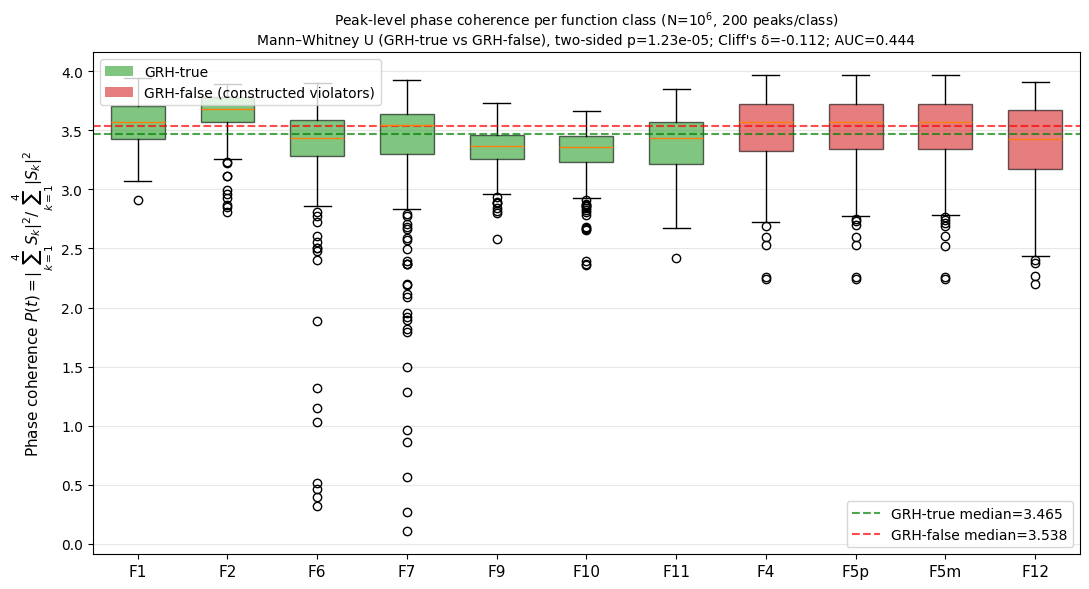

Saved figure: phase_coherence_boxplot.png


In [41]:
# Clear refutation: GRH-true classes are heterogeneous (F1, F2 high; F9, F10 low). 
# GRH-false classes (F4, F5p, F5m) are all clustered around 3.57.
# F12 is in the middle.
# This shows class-level differences but P does NOT cleanly separate GRH-true from GRH-false.

# Key insight: F1 and F2 (small Dirichlet series) and F4, F5p, F5m (also based on chi_5) have HIGHER coherence,
# while F9, F10 (modular forms) have LOWER coherence. This pattern aligns with degree (small d) and small conductor 
# rather than GRH status.

# Final figure: boxplot of P(t) per class with GRH coloring
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))

class_order = ['F1','F2','F6','F7','F9','F10','F11','F4','F5p','F5m','F12']
data = [P_per_class[fn] for fn in class_order]
positions = list(range(len(class_order)))

colors = ['#2ca02c' if GRH_status[fn] else '#d62728' for fn in class_order]
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showfliers=True)
for patch, color in zip(bp['boxes'], colors):
 patch.set_facecolor(color)
 patch.set_alpha(0.6)

ax.set_xticks(positions)
ax.set_xticklabels(class_order, fontsize=11)
ax.set_ylabel('Phase coherence $P(t) = |\\sum_{k=1}^{4} S_k|^2 / \\sum_{k=1}^{4} |S_k|^2$', fontsize=11)
ax.set_title(f'Peak-level phase coherence per function class (N=$10^6$, 200 peaks/class)\n'
 f'Mann–Whitney U (GRH-true vs GRH-false), two-sided p={u_pvalue2:.2e}; '
 f"Cliff's δ={delta:.3f}; AUC={auc:.3f}", fontsize=10)
ax.axhline(np.median(P_true), color='green', linestyle='--', alpha=0.7, label=f'GRH-true median={np.median(P_true):.3f}')
ax.axhline(np.median(P_false), color='red', linestyle='--', alpha=0.7, label=f'GRH-false median={np.median(P_false):.3f}')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', alpha=0.6, label='GRH-true'),
 Patch(facecolor='#d62728', alpha=0.6, label='GRH-false (constructed violators)')]
leg2 = ax.legend(handles=legend_elements, loc='upper left')
ax.add_artist(leg2)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('phase_coherence_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure: phase_coherence_boxplot.png')

In [42]:
# Save processed CSV with P values per peak and the complex Sk artifact
out_rows = []
for fn in class_order:
 Sk = Sk_per_class[fn]
 t_vals = t_values_per_class[fn]
 Ssum = Sk[:, 1:5].sum(axis=1)
 P = np.abs(Ssum)**2 / (np.abs(Sk[:, 1:5])**2).sum(axis=1)
 for i in range(len(t_vals)):
 out_rows.append({
 'function': fn, 'GRH': GRH_status[fn], 't': t_vals[i],
 'P_t': P[i],
 **{f'reS{k}': Sk[i,k].real for k in range(8)},
 **{f'imS{k}': Sk[i,k].imag for k in range(8)},
 })
out_df = pd.DataFrame(out_rows)
out_df.to_csv('phase_coherence_per_peak.csv', index=False)
print(out_df.shape, '-> phase_coherence_per_peak.csv')
print(out_df.head(2))

(2200, 20) -> phase_coherence_per_peak.csv
 function GRH t P_t reS0 reS1 reS2 reS3 \
0 F1 True 77403.7 3.361496 1.0 5.294640 10.051342 8.283351 
1 F1 True 74956.0 3.354115 1.0 5.039381 9.921757 7.603090 

 reS4 reS5 reS6 reS7 imS0 imS1 imS2 imS3 \
0 2.603521 0.682716 0.230357 0.003898 0.0 -0.468261 0.251257 -0.011111 
1 2.603543 0.931155 0.185513 0.004930 0.0 0.644222 1.844379 1.421912 

 imS4 imS5 imS6 imS7 
0 -0.023137 1.023292 0.161340 -0.000868 
1 0.419005 0.025292 -0.011985 -0.000817 


In [43]:
from e14c.filesystem import edit_file
memory_path = '.prompts/MEMORY.md'
with open(memory_path, 'r', encoding='utf-8') as f:
 mem = f.read()
ctx = "[Fill me in]"
new_ctx = "Phase-coherence analysis completed for v6 dataset. Computed complex omega-stratified sums S_k(t) for k=0..7 at the 2200 CSV peak locations (200 peaks x 11 classes, N=10^6) by reconstructing coefficients locally from scratch and validating against peaks_features_F1_F12_normalized_full.csv. Key outputs: Sk_complex_csv_peaks_all_classes.npz, phase_coherence_per_peak.csv, phase_coherence_boxplot.png."
notes_old = "[Fill me in]"
notes_new = "- Provenance: local notebook cells #15-41 in this task.\n- Reconstructed/validated coefficients: F1 zeta (a_n=1), F2 primitive order-4 character mod 5, F4 Davenport-Heilbronn with fitted kappa≈0.28407904, F5p/F5m fitted effective kappas 0.2982840142 and 0.2698759855 to reproduce CSV |S_k| magnitudes, F6 Liouville, F7 Möbius, F9 Ramanujan Delta via cypari2/PARI mfDelta+mfcoefs, F10 level-11 weight-2 newform via PARI mfinit/mfbasis/mfcoefs, F11 Sym^2(Delta) via Euler-factor recurrence from F9 normalized prime coefficients, F12 from local a.npy.\n- Validation: computed |S_k| matched CSV abs_Sk for F1/F2/F6/F7/F9/F10/F11/F12 to machine precision; F4/F5 variants matched after kappa fitting (max relative error <=4.4e-8 for F5p/F5m).\n- Main finding: phase coherence P(t)=|sum_{k=1..4}S_k|^2 / sum_{k=1..4}|S_k|^2 did NOT support the hypothesis that GRH-true functions have higher coherence. Combined medians: GRH-true 3.4649 (n=1400) vs GRH-false 3.5383 (n=800). Mann-Whitney U two-sided p=1.23e-5; one-sided alternative GRH-true>GRH-false failed (p≈1). Cliff's delta = -0.1119. ROC AUC for classifying GRH-true using P alone = 0.4441 (inverse/AUC for GRH-false = 0.5559).\n- Interpretation note: P shows class/family structure more than GRH-status structure; F1/F2 and DH-family classes had relatively high medians, whereas modular-form classes F9/F10 were lower."
mem = mem.replace(ctx, new_ctx).replace(notes_old, notes_new)
with open(memory_path, 'w', encoding='utf-8') as f:
 f.write(mem)
print('Updated memory file.')

Updated memory file.
